# Inflación: dos figuras separadas
Genera una figura para el panel superior y otra figura con los dos paneles inferiores.


/Users/emiliahernandez/Desktop/Banxico/.venv/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/emiliahernandez/Desktop/Banxico/.venv/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/emiliahernandez/Desktop/Banxico/.venv/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


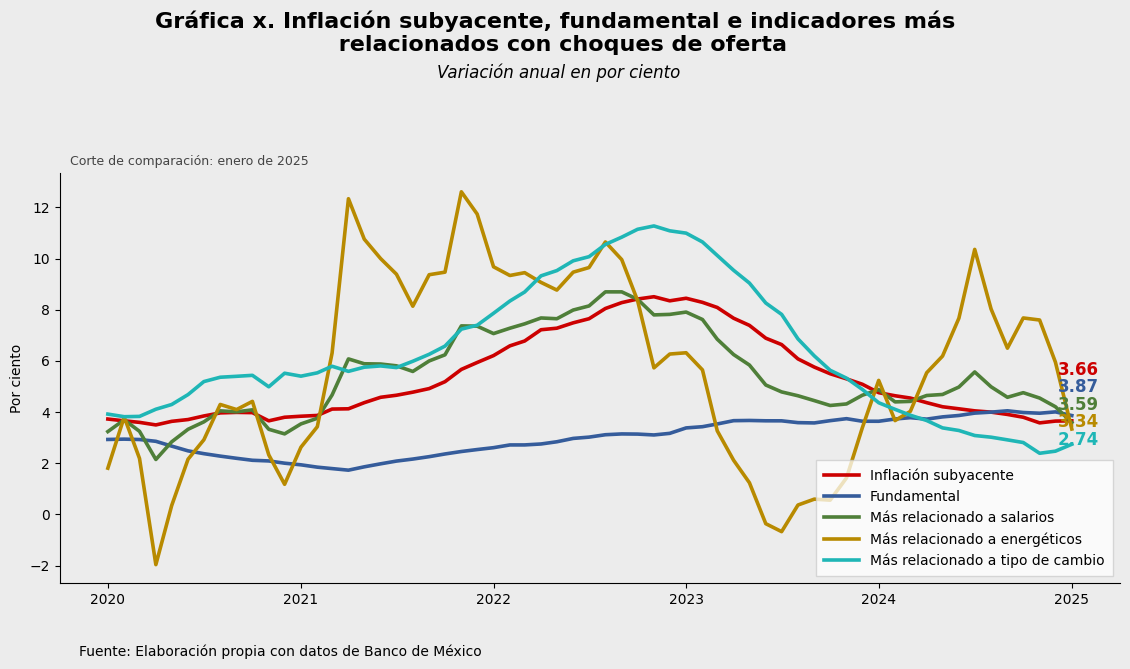

/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_16061/667324875.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0.08, 0.98, 0.88])


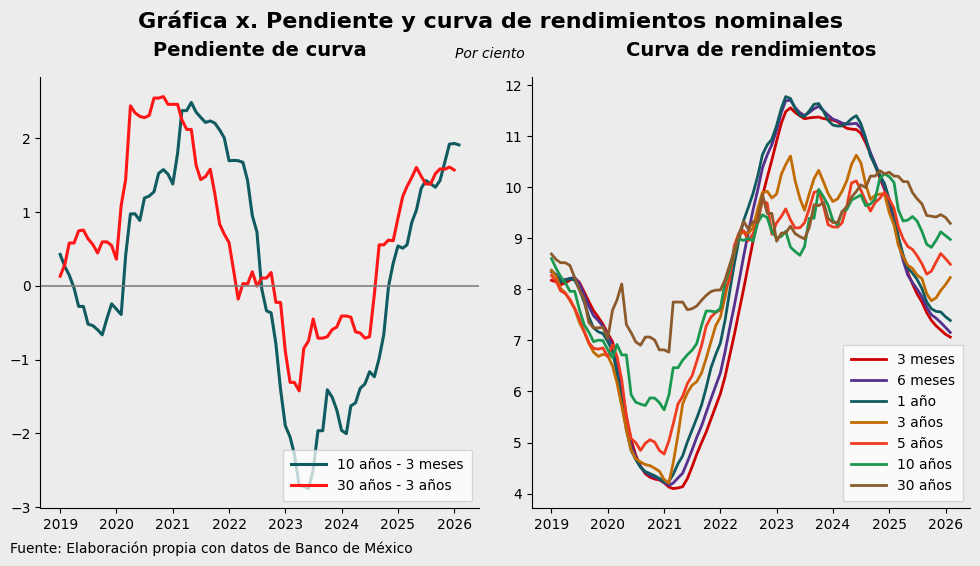

In [5]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path('.')


def read_banxico_excel(path: Path) -> pd.DataFrame:
    raw = pd.read_excel(path, header=None)

    title_row = raw.index[raw.iloc[:, 0].astype(str).str.strip().eq('Título')][0]
    code_row = raw.index[raw.iloc[:, 0].astype(str).str.strip().eq('Fecha')][0]

    codes = [str(c).strip() for c in raw.iloc[code_row, 1:].tolist()]
    titles = [str(t).strip() for t in raw.iloc[title_row, 1:].tolist()]

    cols = ['fecha']
    seen = {}
    for code, _title in zip(codes, titles):
        seen[code] = seen.get(code, 0) + 1
        if seen[code] == 1:
            cols.append(code)
        else:
            cols.append(f'{code}_{seen[code]}')

    df = raw.iloc[code_row + 1 :, : len(cols)].copy()
    df.columns = cols
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df = df.dropna(subset=['fecha']).sort_values('fecha').reset_index(drop=True)

    for c in df.columns[1:]:
        df[c] = pd.to_numeric(df[c].replace('N/E', pd.NA), errors='coerce')

    return df


def yoy(series: pd.Series) -> pd.Series:
    return series.pct_change(12) * 100


def smooth(series: pd.Series, window: int = 3) -> pd.Series:
    return series.rolling(window=window, center=True, min_periods=1).mean()


cp151 = read_banxico_excel(BASE / 'CP151.xlsx')
cp154 = read_banxico_excel(BASE / 'CP154.xlsx')
cf114 = read_banxico_excel(BASE / 'CF114.xlsx')

# ----------------------
# Datos panel superior
# ----------------------
# Nota: la referencia visual llega a 2025-01. Este corte ayuda a que el trazo sea comparable.
REF_TOP_END = pd.Timestamp('2025-01-01')

top = pd.DataFrame({'fecha': cp151['fecha']})
top['Inflación subyacente'] = cp151['SP74662']

# "Fundamental" proxy: servicios de vivienda (componente subyacente menos sensible a choques transitorios).
top['Fundamental'] = yoy(cp154.set_index('fecha')['SP66542']).reindex(top['fecha']).values

# "Más relacionado a salarios" proxy: inflación general anual.
top['Más relacionado a salarios'] = cp151['SP30578']

# "Más relacionado a energéticos" proxy: inflación no subyacente anual.
top['Más relacionado a energéticos'] = cp151['SP74665']

# "Más relacionado a tipo de cambio" proxy: mercancías subyacentes (anual).
top['Más relacionado a tipo de cambio'] = yoy(cp154.set_index('fecha')['SP74626']).reindex(top['fecha']).values

top = top[(top['fecha'] >= '2020-01-01') & (top['fecha'] <= REF_TOP_END)].copy()
# ----------------------
# Datos paneles inferiores
# ----------------------
left = pd.DataFrame({'fecha': cf114['fecha']})
left['10 años - 3 meses'] = cf114['SF30057'] - cf114['SF3338']
left['30 años - 3 años'] = cf114['SF60719'] - cf114['SF17990']
left = left[left['fecha'] >= '2019-01-01']

right = pd.DataFrame({'fecha': cf114['fecha']})
curve_map = {
    '3 meses': 'SF3338',
    '6 meses': 'SF3270',
    '1 año': 'SF3367',
    '3 años': 'SF17990',
    '5 años': 'SF18608',
    '10 años': 'SF30057',
    '30 años': 'SF60719',
}
for label, c in curve_map.items():
    right[label] = cf114[c]
right = right[right['fecha'] >= '2019-01-01']

# ----------------------
# Estilo
# ----------------------
bg = '#ececec'
legend_style = dict(
    loc='lower right',
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2,
)

# ======================
# FIGURA 1 (solo arriba)
# ======================
fig1, ax_top = plt.subplots(figsize=(12, 6.8), facecolor=bg)
ax_top.set_facecolor(bg)
ax_top.spines[['top', 'right']].set_visible(False)

colors_top = {
    'Inflación subyacente': '#cc0000',
    'Fundamental': '#355c9b',
    'Más relacionado a salarios': '#4f7f39',
    'Más relacionado a energéticos': '#b88a00',
    'Más relacionado a tipo de cambio': '#1fb6b6',
}
for col, color in colors_top.items():
    ax_top.plot(top['fecha'], top[col], lw=2.6, color=color, label=col)

#ax_top.set_title('Subyacente, fundamental e indicadores de oferta', fontsize=14, fontweight='bold', pad=15)
ax_top.set_ylabel('Por ciento')
ax_top.text(0.01, 1.02, 'Corte de comparación: enero de 2025', transform=ax_top.transAxes, fontsize=9, color='#444444')
ax_top.xaxis.set_major_locator(mdates.YearLocator())
ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_top.legend(**legend_style)

last = top.dropna(subset=list(colors_top.keys())).iloc[-1]
y_positions = np.linspace(0.52, 0.35, 5)
for y_pos, col in zip(y_positions, colors_top):
    ax_top.text(
        0.98,
        y_pos,
        f"{last[col]:.2f}",
        transform=ax_top.transAxes,
        ha='right',
        va='center',
        color=colors_top[col],
        fontsize=12,
        fontweight='bold',
    )

fig1.suptitle(
    'Gráfica x. Inflación subyacente, fundamental e indicadores más \n relacionados con choques de oferta',
    fontsize=16,
    fontweight='bold',
    y=0.98,
)
fig1.text(0.5, 0.88, 'Variación anual en por ciento', ha='center', fontsize=12, style='italic')
fig1.text(0.10, 0.03, 'Fuente: Elaboración propia con datos de Banco de México', fontsize=10)
plt.tight_layout(rect=[0.03, 0.08, 0.98, 0.88])
plt.show()

# ======================================
# FIGURA 2 (las dos de abajo juntas)
# ======================================
fig2 = plt.figure(figsize=(12, 5.6), facecolor=bg)
gs = fig2.add_gridspec(1, 2, wspace=0.12)
ax_l = fig2.add_subplot(gs[0, 0])
ax_r = fig2.add_subplot(gs[0, 1])

for ax in [ax_l, ax_r]:
    ax.set_facecolor(bg)
    ax.spines[['top', 'right']].set_visible(False)

ax_l.plot(left['fecha'], smooth(left['10 años - 3 meses'], 3), lw=2.2, color='#0f5b60', label='10 años - 3 meses')
ax_l.plot(left['fecha'], smooth(left['30 años - 3 años'], 3), lw=2.2, color='#ff1616', label='30 años - 3 años')
ax_l.axhline(0, color='gray', lw=1.2)
ax_l.set_title('Pendiente de curva', fontsize=14, fontweight='bold', pad=15)
ax_l.xaxis.set_major_locator(mdates.YearLocator())
ax_l.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_l.legend(**legend_style)

curve_colors = ['#cc0000', '#55308d', '#0f5b60', '#c26b00', '#f03b20', '#1a9850', '#8c5a2b']
for color, (label, _) in zip(curve_colors, curve_map.items()):
    ax_r.plot(right['fecha'], smooth(right[label], 3), lw=2.0, color=color, label=label)

ax_r.set_title('Curva de rendimientos', fontsize=14, fontweight='bold', pad=15)
ax_r.xaxis.set_major_locator(mdates.YearLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_r.legend(**legend_style)

fig2.suptitle('Gráfica x. Pendiente y curva de rendimientos nominales', fontsize=16, fontweight='bold', y=1)
fig2.text(0.5, 0.915, 'Por ciento', ha='center', fontsize=10, style='italic')
fig2.text(0.10, 0.03, 'Fuente: Elaboración propia con datos de Banco de México', fontsize=10)
plt.tight_layout(rect=[0.03, 0.08, 0.98, 0.88])
plt.show()



